# Inverse design of photonic wavelength division demultiplexer

## Overview
We inverse design a 1x4 wavelength demultiplexer (WDM) in silicon photonics splitting 4 wavelengths spaced 20nm apart into 4 output waveguides. Design region is a 8um x 8um square of silicon surrounded by silica cladding. We use differentiable simulation powered adjoint optimization to aim for high channel transmission while minimizing crosstalk. For sake of speed this is done in 2.5D (differs from 3D by only couple lines in the code).


## Geometry

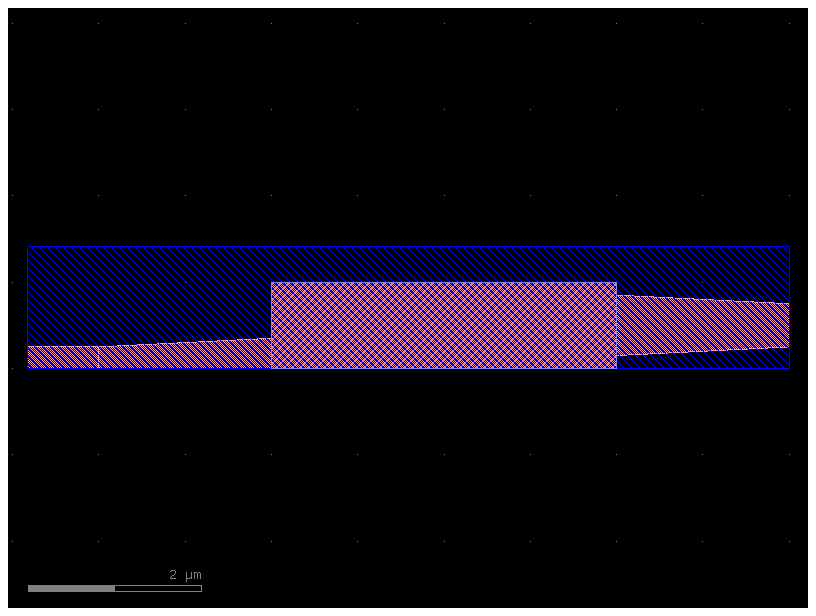

In [3]:
import os
import math
import numpy as np
import luminescent as lumi
import gdsfactory as gf
from gdsfactory.technology import LogicalLayer, LayerLevel, LayerStack
import matplotlib.pyplot as plt


# folder for saving config and results
path = os.path.join("studies", "opt_y")

wavelength=1.301
bandwidth = 0.06
wavelengths = [x for x in np.linspace(wavelength-bandwidth/2, wavelength+bandwidth/2, 4)]

eps_Si = 12.25
eps_SiO2 = 2.1708
n_Si = np.sqrt(eps_Si)
n_SiO2 = np.sqrt(eps_SiO2)
λ_Si=wavelength/n_Si
λ_SiO2=wavelength/n_SiO2

material_wg='Si'
material_clad = "SiO2"

material_library = {
    "Si": lumi.Material(eps_Si),
    "SiO2": lumi.Material(eps_SiO2),
}
material_library["bg"] = material_library["SiO2"]  # set bg material
material_library["design"] = lumi.PlaceholderMaterial(n_Si)

w_wg=.5
l_wg=1
h_wg = 0.22
l_design=4
w_design=1.

# margins
lateral_port_margin = height_port_margin = 1.5*h_wg
margin = 1.25 * lateral_port_margin
zmargin = 1.25 * height_port_margin
source_port_margin = lateral_port_margin+w_wg

nres = 5  # number of grid points per wavelength in material (not vacuum)

zmin=0
zmax=h_wg/2+height_port_margin

WG = 1, 0
BBOX = 10, 0
DESIGN=400,0

# makes gdsfadory component to be optimized. has rectangular design region with port stubs. ports numbered clockwise from bottom left.
c = gf.Component()
taper=0.1
design = c << lumi.mimo(
    l_design,
    w_design,
    layer_wg=WG,
    layer_design=DESIGN,
    init=1,
    west=[w_wg/4],
    east=1,
    w_wg_west=[w_wg/2],
    w_wg_east=[w_wg],
    taper=[(taper/2,0),taper]
)
ext=c<<gf.components.straight(source_port_margin,width=w_wg/2)
ext.connect('o2',design.ports['o1'])

source_port=f'o1'
for i in (1,2):
    c.add_port(f'o{i}', port=design.ports[f'o{i}'])

c << gf.components.bbox(
    component=c, layer=BBOX, top=margin
)
c.plot()

## Solve

saving mode plots to /home/weihu/lumi/luminescent/studies/opt_y/modes/1
showing modes for wavelength 1.301
mode Boundary conditions: 0AA0
/home/weihu/lumi/luminescent/studies/opt_y/modes/1/1.301 mode 0 (neff=2.726+0.000j)
/home/weihu/lumi/luminescent/studies/opt_y/modes/1/1.301 mode 1 (neff=1.063+0.000j)
saving mode plots to /home/weihu/lumi/luminescent/studies/opt_y/modes/2
showing modes for wavelength 1.301
mode Boundary conditions: 0A00
/home/weihu/lumi/luminescent/studies/opt_y/modes/2/1.301 mode 0 (neff=2.786+0.000j)
/home/weihu/lumi/luminescent/studies/opt_y/modes/2/1.301 mode 1 (neff=1.997+0.000j)
using simulation folder /home/weihu/lumi/luminescent/studies/opt_y


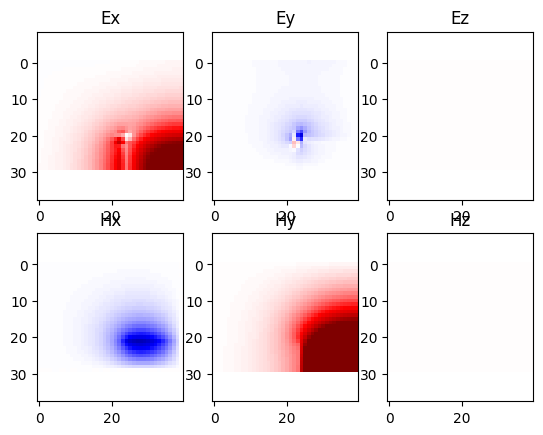

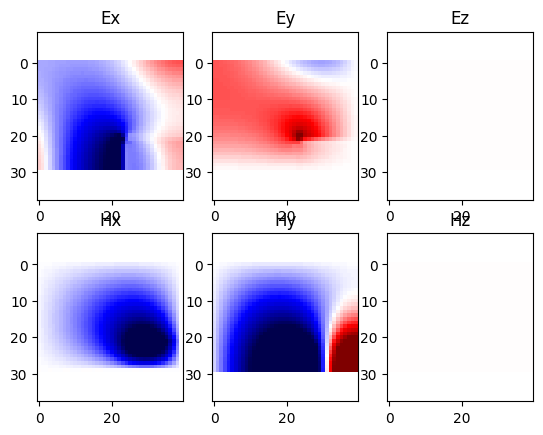

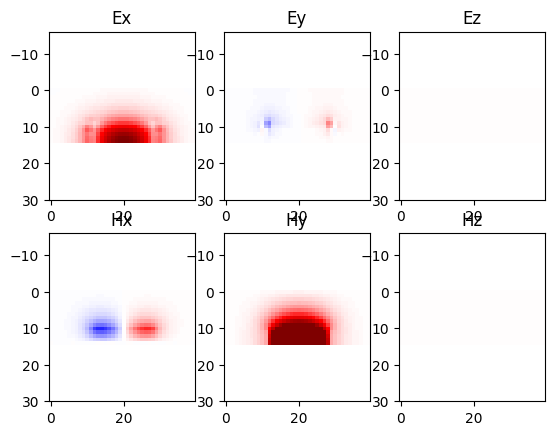

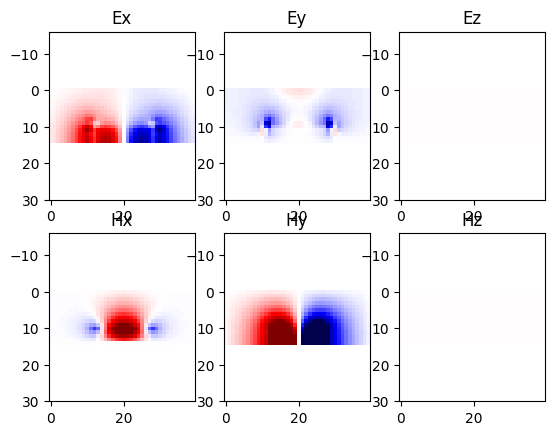

In [4]:
# layer stack. lower mesh order layers override higher mesh order layers. for 2.5D problems as is here, the mesher will slice thru middle of 'core' layer
layers = {
    "wg": LayerLevel(
        layer=LogicalLayer(layer=WG),
        zmin=0,
        thickness=h_wg/2,
        material='Si',
        mesh_order=100,
    ),
    "design": LayerLevel(
        layer=LogicalLayer(layer=DESIGN),
        zmin=0,
        thickness= h_wg/2,
        material="design",
        mesh_order=1,
    ),
}
layer_stack = LayerStack(layers=layers)

lx = w_wg + 2 * lateral_port_margin
ly = h_wg + 2 * height_port_margin
modes = [
    lumi.Mode(
        ports=[source_port],
        start=[-lateral_port_margin-w_wg/4, 0],
        stop=[w_wg / 4, h_wg /2+ height_port_margin],
        boundaries=[('PML','PEC'),('PMC','PML')]
    ),
    lumi.Mode(
        ports=['o2'],
        start=[-lx / 2, 0],
        stop=[lx / 2, h_wg /2+ height_port_margin],
        boundaries=['PML',('PMC','PML')]
    ),
]

sources = [
    lumi.Source(
        source_port,
        wavelength=wavelength,
        bandwidth=wavelength / 5,
        source_port_margin=source_port_margin,
    )
]

targets =        [
            lumi.Target(
                key=f"To2@0,{source_port}@0",
                target=1,
                weight=1 / len(wavelengths),
                wavelength=wl,
                func="relu-",
            )
            for wl in wavelengths        ]

tmax = 1.2 *(l_design+w_design+2*l_wg)* n_Si / wavelength

lmin = 0.15
designs = [
    lumi.Design(
        "design",
        layer=DESIGN,
        lmin=lmin,
        fill_material=material_wg,
        void_material=material_clad,
        uniform_along="z",
    ),
]

optimizer = lumi.Optimizer(
    stoploss=0.05,
    lowloss=0.5,
    iters=30,  # max iters
)

boundaries=['PML',('PEC','PML'),('PMC','PML')]

relative_pml_depths = [1,1,.3]
material_color_map = {
    "bg": "transparent",
    'Si':("black", 0.5),
}
labels={
    'o1':'o1',
    'o2':'o2',
}
show_grid = False
views = [
    lumi.View("Ey",z=0,show_grid=show_grid, labels=labels),
]
# for i in range(nlens1):
#     views.append(lumi.View("Ey", z=zmins_lens1[i] + h_lens / 2))
# for i in range(nlens2):
#     views.append(lumi.View("Ey", z=zmins_lens2[i] + h_lens / 2))

relative_courant = 0.95
saveat = 10  # save frame every `saveat` periods for movie
# saveat = 1

lumi.make(
    #
    path=path,  # path to make problem folder
    component=c,
    wavelength=wavelength,
    wavelengths=wavelengths,
    modes=modes,
    sources=sources,
    boundaries=boundaries,
    #
    material_library=material_library,
    layer_stack=layer_stack,
    #
    zmin=zmin,  # zmin of simulation region
    zmax=zmax,  # zmax of simulation region
    #
    nres=nres,
    tmax=tmax,  # total simulation time in periods
    relative_pml_depths=relative_pml_depths,
    relative_courant=relative_courant,
    saveat=saveat,
    #
    views=views,
    # inverse design parameters
    # load_saved_designs=True,
    designs=designs,
    targets=targets,
    optimizer=optimizer,
)

## Post optimization simulation

In [5]:
# new simulation with optimized design and finer spaced wavelengths
# del kwargs['targets']
# del kwargs['optimizer']
# wavelengths1=np.linspace(1.26, 1.34, 81)
# kwargs.update(
#     wavelengths=wavelengths1,
#     load_saved_designs=True)
# lumi.make(**kwargs)
# lumi.solve(path)

In [6]:
sol = lumi.load(path)
x = wavelengths1
ys = [lumi.query(sol, f"To{i}@0,o1@0") for i in range(2, 6)]
plt.figure()
for y in ys:
    plt.plot(x, [10*math.log10( y) for y in y])
plt.scatter(wavelengths, [0]*len(wavelengths), 100, marker="*")
plt.xlabel("wavelength [um]")
plt.ylabel("transmission [dB]")
plt.show()

loading solution from /home/weihu/lumi/luminescent/studies/opt_y
may take a minute if simulation folder is remotely mounted


FileNotFoundError: [Errno 2] No such file or directory: '/home/weihu/lumi/luminescent/studies/opt_y/.solution.json.tar'